In [ ]:
# 평균 배송 시간 분석

In [1]:
import pandas as pd

PATH = "00_data/"

payments = pd.read_csv(f"{PATH}olist_order_payments_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}olist_orders_dataset.csv", encoding="utf-8-sig")
products = pd.read_csv(f"{PATH}olist_products_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}olist_order_items_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}olist_order_reviews_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}product_category_name_translation.csv", encoding="utf-8-sig")

In [2]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [5]:
orders = orders.dropna()

In [8]:
import pandas as pd

orders["delivery_time"] = pd.to_datetime(orders["order_delivered_customer_date"]) - pd.to_datetime(orders["order_purchase_timestamp"])

In [9]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8 days 10:28:40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13 days 18:46:08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9 days 09:27:40
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13 days 05:00:36
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2 days 20:58:23


In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       96461 non-null  object         
 1   customer_id                    96461 non-null  object         
 2   order_status                   96461 non-null  object         
 3   order_purchase_timestamp       96461 non-null  object         
 4   order_approved_at              96461 non-null  object         
 5   order_delivered_carrier_date   96461 non-null  object         
 6   order_delivered_customer_date  96461 non-null  object         
 7   order_estimated_delivery_date  96461 non-null  object         
 8   delivery_time                  96461 non-null  timedelta64[ns]
dtypes: object(8), timedelta64[ns](1)
memory usage: 7.4+ MB


In [11]:
orders["delivery_time"].describe()

count                         96461
mean     12 days 13:23:46.585853350
std       9 days 13:06:45.121880865
min                 0 days 12:48:07
25%                 6 days 18:22:50
50%                10 days 05:11:29
75%                15 days 17:17:10
max               209 days 15:05:12
Name: delivery_time, dtype: object

In [14]:
# 1분 = 60초
# 1시간 = 3600초
# 1일 = 86,400초

import pandas as pd
import plotly.express as px

orders["delivery_time_days"] = orders["delivery_time"].dt.total_seconds() / 86400 # 제각각으로 표시되어있던 시간들을 초 단위로 변환

In [15]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8 days 10:28:40,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13 days 18:46:08,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9 days 09:27:40,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13 days 05:00:36,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2 days 20:58:23,2.873877


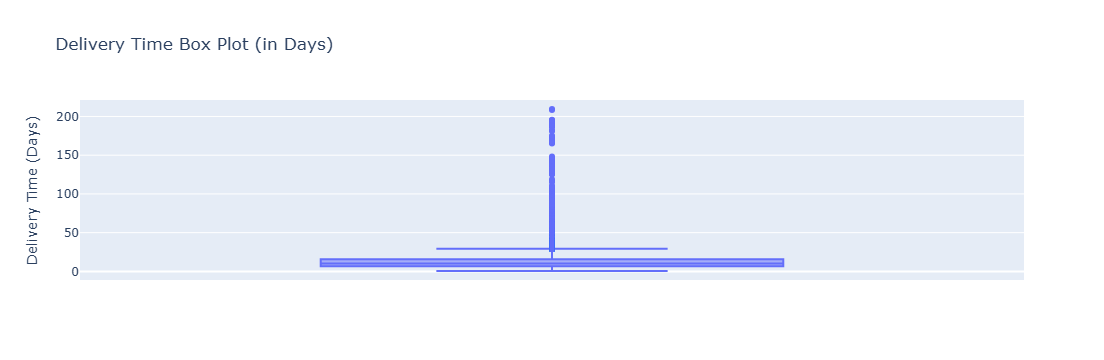

In [17]:
import pandas as pd
import plotly.express as px

fig = px.box(
    orders,
    y = "delivery_time_days",
    title = "Delivery Time Box Plot (in Days)",
    labels={
        "delivery_time_days": "Delivery Time (Days)"
    }
)

fig.show()

In [18]:
# 현재 데이터를 기준으로 보았을 때, 지나친 이상치값들로 인해서 전체 평균 값이 왜곡되는 현상이 나타남
# 이상치 값을 제거하고 정상치의 값들로만 평균을 알아보기
# quantile() : 해당 매서드에 들어오는 범위의 값을 제거한 후 평균을 산정한다

delivery_time_q95 = orders["delivery_time"].quantile(.95) # .95 : 0 ~ 95까지의 값

In [19]:
delivery_time_q95

Timedelta('29 days 06:36:33')

In [20]:
delivery_time_q95 = orders["delivery_time"].quantile(.90)

In [21]:
delivery_time_q95

Timedelta('23 days 02:21:07')

In [22]:
orders = orders[orders["delivery_time"] < delivery_time_q95]

In [23]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8 days 10:28:40,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13 days 18:46:08,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9 days 09:27:40,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13 days 05:00:36,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2 days 20:58:23,2.873877
...,...,...,...,...,...,...,...,...,...,...
99435,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22 00:00:00,11 days 02:02:56,11.085370
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,8 days 05:13:56,8.218009
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,22 days 04:38:58,22.193727
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,17 days 02:04:27,17.086424


In [ ]:
# 월별 평균 배송 시간 분석

In [29]:
orders_date = orders[["order_purchase_timestamp", "delivery_time_days"]].copy()

In [30]:
orders_date

,order_purchase_timestamp,delivery_time_days
0,2017-10-02 10:56:33,8.436574
1,2018-07-24 20:41:37,13.782037
2,2018-08-08 08:38:49,9.394213
3,2017-11-18 19:28:06,13.208750
4,2018-02-13 21:18:39,2.873877
...,...,...
99435,2017-02-23 09:05:12,11.085370
99436,2017-03-09 09:54:05,8.218009
99437,2018-02-06 12:58:58,22.193727
99439,2018-01-08 21:28:27,17.086424


In [31]:
orders_date.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86814 entries, 0 to 99440
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_purchase_timestamp  86814 non-null  object 
 1   delivery_time_days        86814 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.0+ MB


In [32]:
orders_date["order_purchase_timestamp"] = pd.to_datetime(orders_date["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [33]:
orders_date = orders_date.set_index("order_purchase_timestamp")

In [34]:
orders_date

,delivery_time_days
order_purchase_timestamp,
2017-10-02 10:56:33,8.436574
2018-07-24 20:41:37,13.782037
2018-08-08 08:38:49,9.394213
2017-11-18 19:28:06,13.208750
2018-02-13 21:18:39,2.873877
...,...
2017-02-23 09:05:12,11.085370
2017-03-09 09:54:05,8.218009
2018-02-06 12:58:58,22.193727


In [35]:
import pandas as pd

orders_date = orders_date.groupby(pd.Grouper(freq="ME")).mean()

In [36]:
orders_date.head()

,delivery_time_days
order_purchase_timestamp,
2016-10-31,13.210816
2016-11-30,NaN
2016-12-31,4.693021
2017-01-31,10.753599
2017-02-28,10.992469


In [38]:
orders_date = orders_date[orders_date.index >= "2017-01-01"]

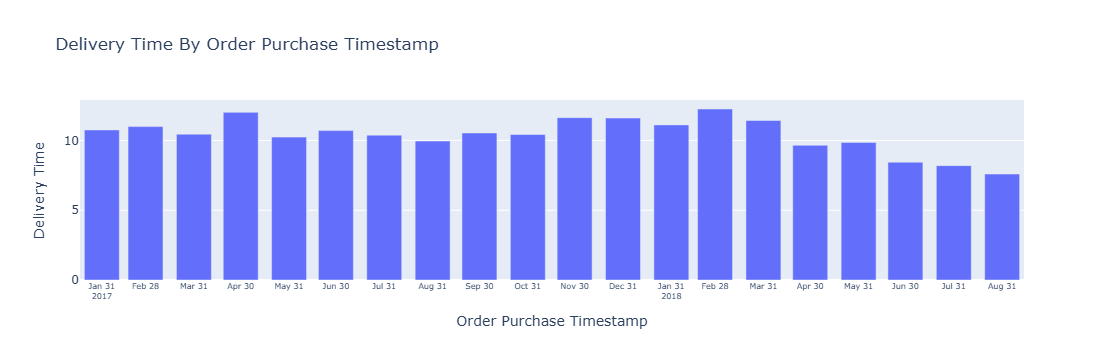

In [41]:
import plotly.express as px

fig = px.bar(
    x=orders_date.index,
    y=orders_date["delivery_time_days"],
    title="Delivery Time By Order Purchase Timestamp",
    labels={
        "x": "Order Purchase Timestamp",
        "y": "Delivery Time"
    }
)

fig.update_layout(
    xaxis = {
        "showticklabels": True,
        "tick0": "2017-01-31",
        "dtick": "M1",
        "tickfont": {
            "size": 8
        }
    }
)

fig.show()